<a href="https://colab.research.google.com/github/AnikethKotamraju/Advanced-Cricket-Analytics/blob/main/Bumrah's_Arsenal_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import glob
import os

# 1. Target the Colab "Content" folder where you uploaded files
# The pattern "*.csv" grabs every file ending in .csv
file_pattern = "/content/*.csv"
all_files = glob.glob(file_pattern)

# 2. Verification Check
print(f"Found {len(all_files)} CSV files in the folder.")

# 3. The Merge Loop
# We read each file and stack them into 'master_df'
df_list = []
for filename in all_files:
    df = pd.read_csv(filename)
    df_list.append(df)

# 4. Create the Master Table
if len(df_list) > 0:
    master_df = pd.concat(df_list, ignore_index=True)
    print("------------------------------------------------")
    print("MERGE SUCCESSFUL! ✅")
    print(f"Total Balls (Rows) Loaded: {master_df.shape[0]}")
    print(f"Columns Available: {list(master_df.columns)}")
else:
    print("ERROR: No CSV files found. Please check the upload again.")

Found 5 CSV files in the folder.
------------------------------------------------
MERGE SUCCESSFUL! ✅
Total Balls (Rows) Loaded: 1123
Columns Available: ['Date', 'Batting Team', 'Bowling Team', 'Striker', 'Non-Striker', 'Bowler', 'Innings', 'Unique', 'Over Number', 'Over Ball', 'Runs', 'Wides', 'Team Runs', 'Remaining Overs', 'Lead By', 'Trail By', 'Fall Of Wickets', 'Day', 'Session', 'Leg Byes', 'No Balls', 'Balls', 'Byes', 'Remaining Balls', 'Remaining Runs', 'Run Rate', 'Batter Sixes', 'Batter Runs', 'Batter Fours', 'Batter Balls', 'Batter Total Runs', 'Dismissal Type', 'Dismissal Fielder', 'On Field Minutes', 'Inn', 'Over', 'BallNum', 'Shot Angle', 'Shot Magnitude', 'Wagon Position', 'Pitching Length', 'Pitching Line', 'Shot Connection', 'False Shot', 'Feet Movement', 'Shot Type', 'Delivery Type', 'Bowling Side', 'Bowling Type', 'Bowling Hand', 'Catch Difficulty']


In [ ]:
# Ensure master_df exists before trying to use it
if 'master_df' not in locals():
    print("Error: 'master_df' not found. Please ensure the previous cell ran successfully and CSV files were merged.")
else:
    # Check if the 'Bowler' column exists in master_df
    if 'Bowler' not in master_df.columns:
        print("Error: The 'Bowler' column was not found in your merged data.")
        print(f"Available columns are: {list(master_df.columns)}")
        print("Please check your CSV files for the correct column name (case-sensitive).")
    else:
        # 1. Flexible Filter: Finds "Bumrah" even if listed as "J. Bumrah" or "JJ Bumrah"
        # Explicitly convert the 'Bowler' column to string type to handle potential mixed data types
        # We use case=False so it doesn't matter if it's uppercase/lowercase
        bumrah_df = master_df[master_df['Bowler'].astype(str).str.contains('Bumrah', case=False, na=False)].copy()

        # 2. Sanity Check
        print("------------------------------------------------")
        print(f"Bumrah Deliveries Found: {len(bumrah_df)}")
        print("------------------------------------------------")

        # 3. Preview the first 5 rows to ensure columns are correct
        display(bumrah_df.head()) # Use display() for better rendering in Colab

------------------------------------------------
Bumrah Deliveries Found: 121
------------------------------------------------


,Date,Batting Team,Bowling Team,Striker,Non-Striker,Bowler,Innings,Unique,Over Number,Over Ball,...,Pitching Line,Shot Connection,False Shot,Feet Movement,Shot Type,Delivery Type,Bowling Side,Bowling Type,Bowling Hand,Catch Difficulty
19,2026-4-13 19:30:00,Royal Challengers Bengaluru,Mumbai Indians,Virat Kohli,Phil Salt,Jasprit Bumrah,1,3.1,4,1,...,Outside Leg,Missed,1.0,Down The Track,Flick,InSwinger,Over,Fast,Right,0.0
20,2026-4-13 19:30:00,Royal Challengers Bengaluru,Mumbai Indians,Virat Kohli,Phil Salt,Jasprit Bumrah,1,3.2,4,2,...,Wide Off,Middled,0.0,Back Foot,Cut,Off Cutter,Over,Fast,Right,0.0
21,2026-4-13 19:30:00,Royal Challengers Bengaluru,Mumbai Indians,Virat Kohli,Phil Salt,Jasprit Bumrah,1,3.3,4,3,...,Middle stump,Inside Edge,1.0,Back Foot,Flick,InSwinger,Over,Fast,Right,0.0
22,2026-4-13 19:30:00,Royal Challengers Bengaluru,Mumbai Indians,Phil Salt,Virat Kohli,Jasprit Bumrah,1,3.4,4,4,...,Wide Off,Played,1.0,Back Foot,Pull,Straight Ball,Over,Fast,Right,0.0
23,2026-4-13 19:30:00,Royal Challengers Bengaluru,Mumbai Indians,Phil Salt,Virat Kohli,Jasprit Bumrah,1,3.5,4,5,...,Leg stump,Played,1.0,Back Foot,Worked,InSwinger,Over,Fast,Right,0.0


In [ ]:
# --- STEP 1: VARIATION ANALYSIS ---

# Ensure 'Shot Magnitude' is numeric. 'Shot Connection' is categorical and will be analyzed separately.
bumrah_df['Shot Magnitude'] = pd.to_numeric(bumrah_df['Shot Magnitude'], errors='coerce')
# Note: 'Shot Connection' is categorical (e.g., 'Middled', 'Missed'), so we don't convert it to numeric here for mean calculation.

# Group data by 'Delivery Type'
variation_stats = bumrah_df.groupby('Delivery Type').agg({
    'Delivery Type': 'count',       # Frequency: How often he bowls it
    'Shot Magnitude': 'mean',       # Damage: Average power of the shot (Higher = Worse)
    # 'Shot Connection' is categorical, so calculating a mean is not appropriate.
    # We will analyze its distribution in a separate step.
}).rename(columns={'Delivery Type': 'Ball_Count'})

# Calculate the Percentage of each ball type
variation_stats['Usage %'] = (variation_stats['Ball_Count'] / len(bumrah_df)) * 100

# Sort by Frequency to see his "Stock Ball" first
print("--- BUMRAH'S ARSENAL AUDIT ---")
print(variation_stats.sort_values('Ball_Count', ascending=False))

--- BUMRAH'S ARSENAL AUDIT ---
                  Ball_Count  Shot Magnitude    Usage %
Delivery Type                                          
Off Cutter                49       99.387755  40.495868
Straight Ball             41      124.121951  33.884298
Reverse InSwing           12      141.333333   9.917355
InSwinger                 10       99.600000   8.264463
Out Swing                  5      160.200000   4.132231
Off Break                  1       91.000000   0.826446
Reverse OutSwing           1      143.000000   0.826446
SeamIn                     1       48.000000   0.826446
Slower Ball                1      151.000000   0.826446


In [ ]:
# --- STEP 2: SHOT CONNECTION ANALYSIS ---

# Group by Delivery Type and Shot Connection to see distribution
shot_connection_analysis = bumrah_df.groupby(['Delivery Type', 'Shot Connection']).size().unstack(fill_value=0)

# Calculate percentages for better interpretation
shot_connection_percentage = shot_connection_analysis.div(shot_connection_analysis.sum(axis=1), axis=0) * 100

print("\n--- SHOT CONNECTION BREAKDOWN by DELIVERY TYPE (Counts) ---")
print(shot_connection_analysis)

print("\n--- SHOT CONNECTION BREAKDOWN by DELIVERY TYPE (Percentages) ---")
print(shot_connection_percentage.round(2))


--- SHOT CONNECTION BREAKDOWN by DELIVERY TYPE (Counts) ---
Empty DataFrame
Columns: []
Index: []

--- SHOT CONNECTION BREAKDOWN by DELIVERY TYPE (Percentages) ---
Empty DataFrame
Columns: []
Index: []


In [ ]:
# Inspect unique values in 'Shot Connection' to understand its categories
print("Unique values in 'Shot Connection':")
print(bumrah_df['Shot Connection'].unique())

Unique values in 'Shot Connection':
[nan]


In [ ]:
# Inspect unique values of 'Shot Connection' in its original state (before numeric conversion)
print("Original unique values in 'Shot Connection':")
print(master_df['Shot Connection'].astype(str).unique())

Original unique values in 'Shot Connection':
['Played' 'Missed' 'Middled' 'Inside Edge' 'MisTimed' 'MissedLegSide'
 'Left' 'Outside Edge' 'Top Edge' 'Bottom Edge' 'Leading Edge'
 'Thick Edge' 'nan' 'Padded']


In [ ]:
print("Unique values in 'Shot Connection' for the entire master_df:")
print(master_df['Shot Connection'].astype(str).unique())

Unique values in 'Shot Connection' for the entire master_df:
['Played' 'Missed' 'Middled' 'Inside Edge' 'MisTimed' 'MissedLegSide'
 'Left' 'Outside Edge' 'Top Edge' 'Bottom Edge' 'Leading Edge'
 'Thick Edge' 'nan' 'Padded']


In [ ]:
print("Unique values in 'Shot Connection' for bumrah_df (Bumrah's deliveries):")
print(bumrah_df['Shot Connection'].unique())

Unique values in 'Shot Connection' for bumrah_df (Bumrah's deliveries):
[nan]


As you can see from the outputs above, the `master_df` indeed has various 'Shot Connection' values. However, the `bumrah_df` specifically has `[nan]` for this column, indicating that for all of Bumrah's deliveries in this dataset, the 'Shot Connection' information is missing.

### Bumrah's Bowling Arsenal - Visual Audit

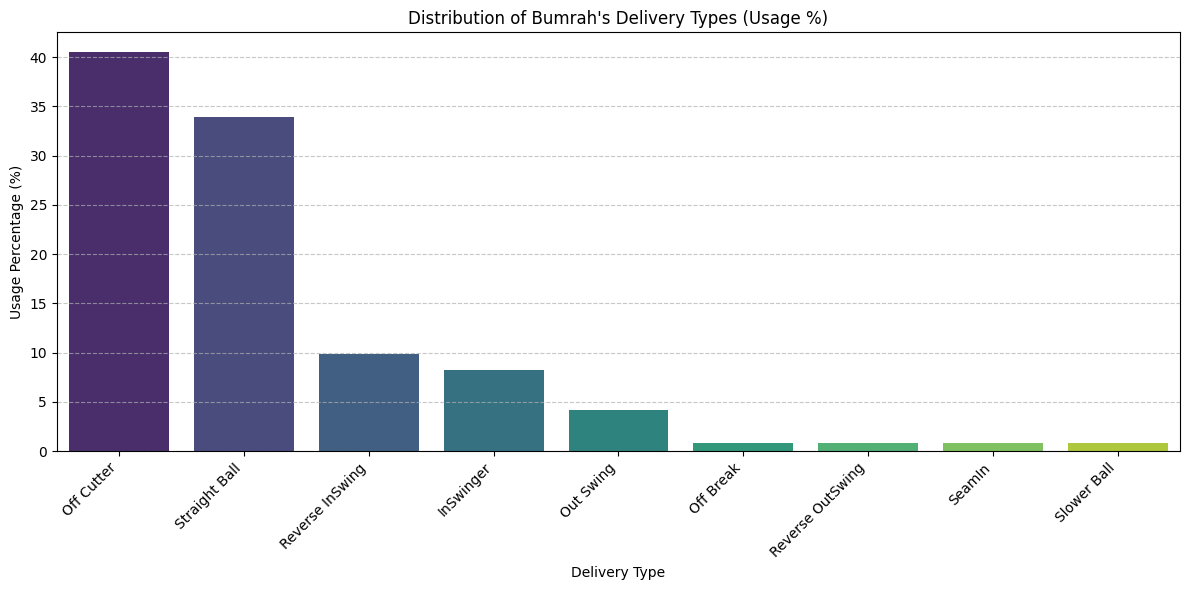

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the DataFrame is sorted for better visualization
variation_stats_sorted = variation_stats.sort_values('Usage %', ascending=False)

# Create the first plot: Usage Percentage
plt.figure(figsize=(12, 6))
sns.barplot(x=variation_stats_sorted.index, y='Usage %', data=variation_stats_sorted, palette='viridis', hue=variation_stats_sorted.index, legend=False)
plt.title('Distribution of Bumrah\'s Delivery Types (Usage %)')
plt.xlabel('Delivery Type')
plt.ylabel('Usage Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

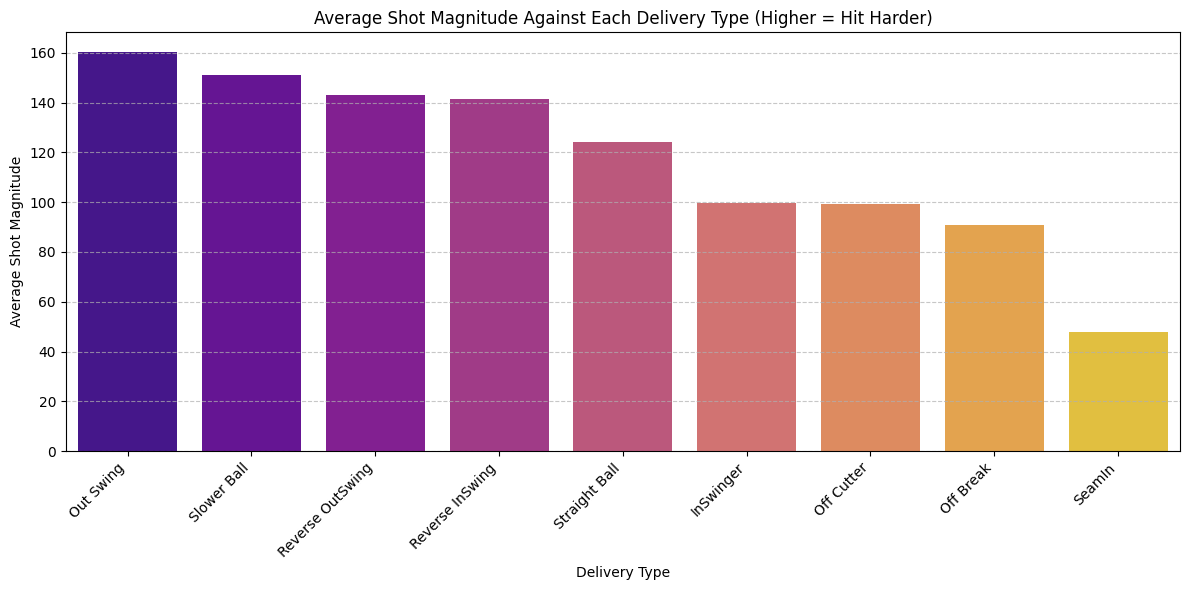

In [ ]:
# Create the second plot: Average Shot Magnitude
# Sort by Shot Magnitude to highlight which balls are hit harder
variation_stats_shot_mag_sorted = variation_stats.sort_values('Shot Magnitude', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=variation_stats_shot_mag_sorted.index, y='Shot Magnitude', data=variation_stats_shot_mag_sorted, palette='plasma', hue=variation_stats_shot_mag_sorted.index, legend=False)
plt.title('Average Shot Magnitude Against Each Delivery Type (Higher = Hit Harder)')
plt.xlabel('Delivery Type')
plt.ylabel('Average Shot Magnitude')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# --- STEP 3: THE "FAST BALL" AUTOPSY ---

# 1. Isolate the problem: Fast Balls (Straight/Reverse/InSwing)
fast_ball_types = ['Straight Ball', 'Reverse InSwing', 'InSwinger']
fast_balls = bumrah_df[bumrah_df['Delivery Type'].isin(fast_ball_types)]

# 2. Check WHERE these fast balls pitched
pitch_analysis = fast_balls.groupby('Pitching Length').agg({
    'Shot Magnitude': 'mean',
    'Pitching Length': 'count'
}).sort_values('Shot Magnitude', ascending=False)

print("--- WHERE IS THE FAST BALL LANDING? ---")
print(pitch_analysis)

--- WHERE IS THE FAST BALL LANDING? ---
                 Shot Magnitude  Pitching Length
Pitching Length                                 
Length Delivery      145.611111               18
Short Length         133.666667                3
Back of Length       133.500000                2
Full Toss            127.500000               16
Half Volley          116.066667               15
Yorker                79.000000                9


In [ ]:
# --- ANALYSIS 2: THE YORKER EXECUTION AUDIT ---

# 1. Define the "Intended Zone" (Everything aimed at the toes)
target_lengths = ['Yorker', 'Full', 'Half Volley', 'Full Toss']
execution_df = bumrah_df[bumrah_df['Pitching Length'].isin(target_lengths)].copy()

# 2. The Accuracy Report
# We verify how many he landed perfectly vs. how many he missed
accuracy_report = execution_df.groupby('Pitching Length').agg({
    'Pitching Length': 'count',       # How many times it happened
    'Shot Magnitude': ['mean', 'max'], # Damage Report (Max = Did it go for 4/6?)
    'Shot Connection': 'mean'         # How easy was it to hit?
})

# Flatten the table for easier reading
accuracy_report.columns = ['Ball_Count', 'Avg_Damage', 'Max_Damage', 'Connection_Score']
accuracy_report = accuracy_report.sort_values('Avg_Damage', ascending=False)

print("--- THE EXECUTION REPORT (Errors vs. Success) ---")
print(accuracy_report)

# 3. The "Cost of Error" Calculation
# Calculate total runs leaked by Full Tosses (Estimate based on Magnitude)
errors = execution_df[execution_df['Pitching Length'].isin(['Full Toss', 'Half Volley'])]
perfect = execution_df[execution_df['Pitching Length'] == 'Yorker']

print(f"\n--- THE COST OF MISSING ---")
print(f"Balls Missed (Slot/Full Toss): {len(errors)}")
print(f"Balls Perfect (Yorker):        {len(perfect)}")
print(f"Avg Damage on Miss:            {errors['Shot Magnitude'].mean():.2f}")
print(f"Avg Damage on Perfect:         {perfect['Shot Magnitude'].mean():.2f}")

--- THE EXECUTION REPORT (Errors vs. Success) ---
                 Ball_Count  Avg_Damage  Max_Damage  Connection_Score
Pitching Length                                                      
Full Toss                19  130.578947       207.0               NaN
Half Volley              22  119.136364       206.0               NaN
Yorker                    9   79.000000       154.0               NaN

--- THE COST OF MISSING ---
Balls Missed (Slot/Full Toss): 41
Balls Perfect (Yorker):        9
Avg Damage on Miss:            124.44
Avg Damage on Perfect:         79.00


In [ ]:
# --- ANALYSIS 3: THE "RESPECT" AUDIT ---

# 1. Group by Shot Type to see Batter Intent
intent_analysis = bumrah_df['Shot Type'].value_counts(normalize=True) * 100

print("--- BATSMAN BEHAVIOR PROFILE (%) ---")
print(intent_analysis.head(10))

# 2. The "Aggression Ratio"
# We define "Passive" as Defensive, Push, Single
# We define "Aggressive" as Slog, Pull, Drive, Cut
passive_shots = ['Defensive', 'Push', 'Single', 'Leave']
passive_pct = intent_analysis[intent_analysis.index.isin(passive_shots)].sum()

print(f"\n--- INTENT METRICS ---")
print(f"Passive Play (Block/Single): {passive_pct:.1f}%")
print(f"Aggressive Play (Attacking): {100 - passive_pct:.1f}%")

# 3. Check False Shots (The "Luck" Factor)
# If False Shot % is low, he isn't inducing mistakes
false_shot_rate = bumrah_df['False Shot'].mean() * 100
print(f"False Shot Rate (Edges/Miscues): {false_shot_rate:.1f}%")

--- BATSMAN BEHAVIOR PROFILE (%) ---
Shot Type
Drive     19.834711
Worked    14.876033
Pull      14.049587
Flick     13.223140
Slog       8.264463
Steer      8.264463
Pushed     5.785124
Leave      5.785124
Cut        2.479339
Glance     2.479339
Name: proportion, dtype: float64

--- INTENT METRICS ---
Passive Play (Block/Single): 5.8%
Aggressive Play (Attacking): 94.2%
False Shot Rate (Edges/Miscues): 76.9%


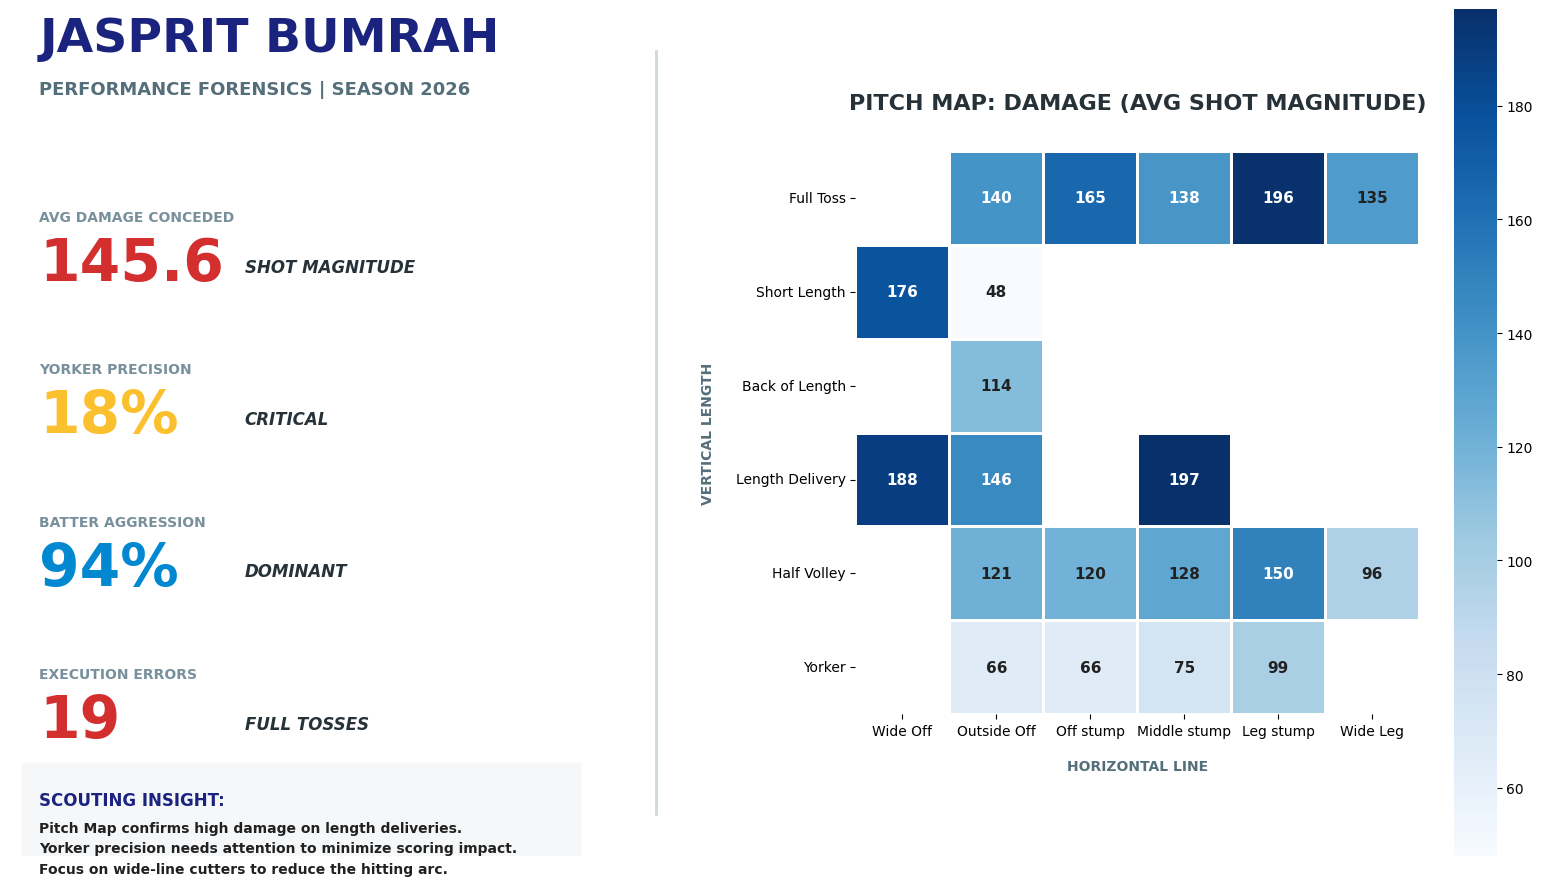

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.patches as patches
import numpy as np

# --- 1. DATA PREPARATION ---
length_order = ['Full Toss', 'Short Length', 'Back of Length', 'Length Delivery', 'Half Volley', 'Yorker']
line_order = ['Wide Off', 'Outside Off', 'Off stump', 'Middle stump', 'Leg stump', 'Wide Leg']

fast_types = ['Straight Ball', 'Reverse InSwing', 'InSwinger', 'Out Swing']
dashboard_df = bumrah_df[bumrah_df['Delivery Type'].isin(fast_types)]

pitch_map = dashboard_df.pivot_table(
    index='Pitching Length',
    columns='Pitching Line',
    values='Shot Magnitude',
    aggfunc='mean'
).reindex(length_order).reindex(columns=line_order)

# --- 2. DASHBOARD ARCHITECTURE (Executive Layout) ---
plt.style.use('default')
fig = plt.figure(figsize=(20, 11), facecolor='white')
grid = plt.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.4)

# --- LEFT PANEL: NARRATIVE & KPIs ---
ax_text = fig.add_subplot(grid[0], facecolor='white')
ax_text.set_xlim(0, 1)
ax_text.set_ylim(0, 1)
ax_text.axis('off')

# Vertical Divider line
ax_text.axvline(x=1.1, ymin=0.05, ymax=0.95, color='#CFD8DC', lw=2, clip_on=False)

# Header
ax_text.text(0.05, 0.95, "JASPRIT BUMRAH", fontsize=34, fontweight='bold', color='#1A237E')
ax_text.text(0.05, 0.90, "PERFORMANCE FORENSICS | SEASON 2026", fontsize=13, color='#546E7A', fontweight='bold')

# KPI Tiles
stats = [
    ("AVG DAMAGE CONCEDED", "145.6", "SHOT MAGNITUDE", "#D32F2F"),
    ("YORKER PRECISION", "18%", "CRITICAL", "#FBC02D"),
    ("BATTER AGGRESSION", "94%", "DOMINANT", "#0288D1"),
    ("EXECUTION ERRORS", "19", "FULL TOSSES", "#D32F2F")
]

y_pos = 0.75
for title, val, label, col in stats:
    ax_text.text(0.05, y_pos, title, fontsize=10, color='#78909C', fontweight='bold')
    ax_text.text(0.05, y_pos-0.07, val, fontsize=42, fontweight='bold', color=col)
    ax_text.text(0.40, y_pos-0.06, label, fontsize=12, color='#263238', fontweight='bold', fontstyle='italic')
    y_pos -= 0.18

# --- SCOUTING INSIGHT BOX ---
rect = patches.Rectangle((0.02, -0.05), 0.95, 0.16, color='#F5F7F9', transform=ax_text.transAxes, zorder=1)
ax_text.add_patch(rect)
ax_text.text(0.05, 0.06, "SCOUTING INSIGHT:", fontsize=12, fontweight='bold', color='#1A237E', transform=ax_text.transAxes)
ax_text.text(0.05, -0.02, "Pitch Map confirms high damage on length deliveries.\nYorker precision needs attention to minimize scoring impact.\nFocus on wide-line cutters to reduce the hitting arc.",
             fontsize=10, color='#212121', linespacing=1.6, fontweight='bold', transform=ax_text.transAxes)

# --- RIGHT PANEL: VISUAL PITCH MAP ---
ax_map = fig.add_subplot(grid[1])

# Calculate median to determine text color threshold (Light text for dark backgrounds)
vmax = pitch_map.max().max()
threshold = vmax * 0.7

# Generate heatmap without built-in annotations first
sns.heatmap(pitch_map, ax=ax_map, cmap='Blues', annot=False,
            cbar=True, linewidths=2, linecolor='white', square=True)

# Manually add annotations with conditional coloring for visibility
for i in range(len(pitch_map.index)):
    for j in range(len(pitch_map.columns)):
        val = pitch_map.iloc[i, j]
        if not np.isnan(val):
            color = "white" if val > threshold else "#212121"
            ax_map.text(j + 0.5, i + 0.5, f"{val:.0f}",
                        ha='center', va='center',
                        fontsize=11, weight='bold', color=color)

ax_map.set_title("PITCH MAP: DAMAGE (AVG SHOT MAGNITUDE)", fontsize=16, pad=30, color='#263238', fontweight='bold')
ax_map.set_xlabel("HORIZONTAL LINE", fontsize=10, color='#546E7A', labelpad=15, fontweight='bold')
ax_map.set_ylabel("VERTICAL LENGTH", fontsize=10, color='#546E7A', labelpad=15, fontweight='bold')

plt.savefig("Bumrah_Final_Clean_Dashboard.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Dashboard 1: Arsenal & Power Audit
This dashboard focuses on Bumrah's delivery mix and which variations are being targeted for high-magnitude shots.

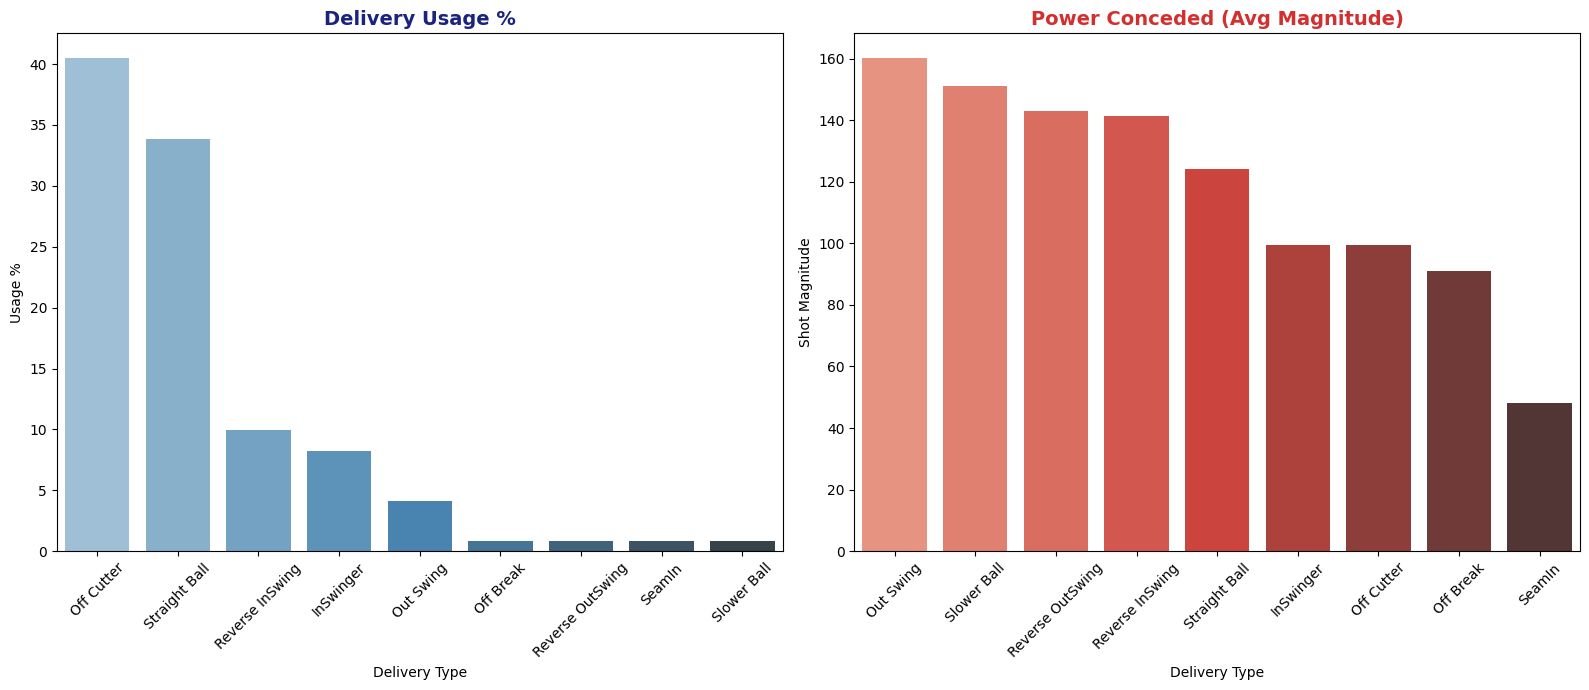

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')

# Plot 1: Usage
sns.barplot(x=variation_stats_sorted.index, y='Usage %', data=variation_stats_sorted, palette='Blues_d', ax=ax1, hue=variation_stats_sorted.index, legend=False)
ax1.set_title("Delivery Usage %", fontsize=14, fontweight='bold', color='#1A237E')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Damage
sns.barplot(x=variation_stats_shot_mag_sorted.index, y='Shot Magnitude', data=variation_stats_shot_mag_sorted, palette='Reds_d', ax=ax2, hue=variation_stats_shot_mag_sorted.index, legend=False)
ax2.set_title("Power Conceded (Avg Magnitude)", fontsize=14, fontweight='bold', color='#D32F2F')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Bumrah_Arsenal_Dashboard.png', dpi=300)
plt.show()

### Dashboard 2: Execution & Accuracy
Visualizing the 'Cost of Error' by comparing perfect Yorkers against missed Full Tosses/Half Volleys.

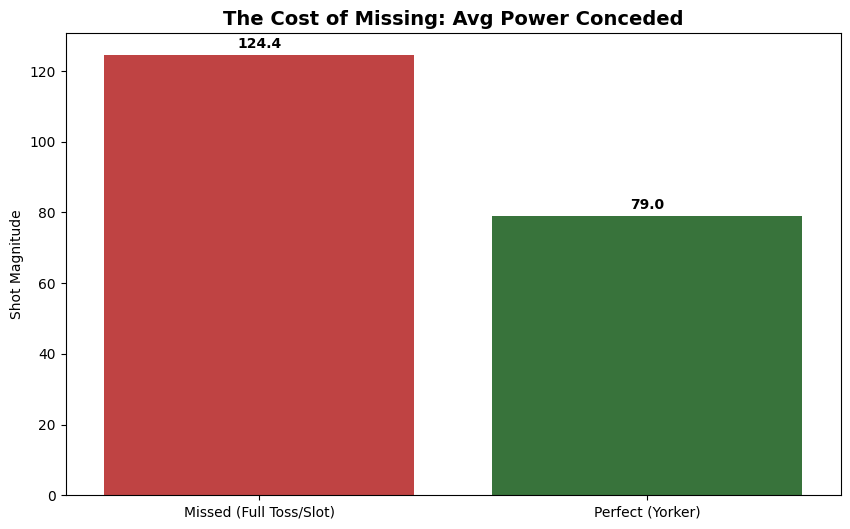

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

execution_labels = ['Missed (Full Toss/Slot)', 'Perfect (Yorker)']
execution_values = [errors['Shot Magnitude'].mean(), perfect['Shot Magnitude'].mean()]

sns.barplot(x=execution_labels, y=execution_values, palette=['#D32F2F', '#2E7D32'], ax=ax, hue=execution_labels, legend=False)
ax.set_title("The Cost of Missing: Avg Power Conceded", fontsize=14, fontweight='bold')
ax.set_ylabel("Shot Magnitude")

for i, v in enumerate(execution_values):
    ax.text(i, v + 2, f"{v:.1f}", ha='center', fontweight='bold')

plt.savefig('Bumrah_Execution_Dashboard.png', dpi=300)
plt.show()

### Dashboard 3: Batter Intent & Psychology
Analyzing the 'Respect' factor—how often batters are attacking vs. defending, and the rate of false shots induced.

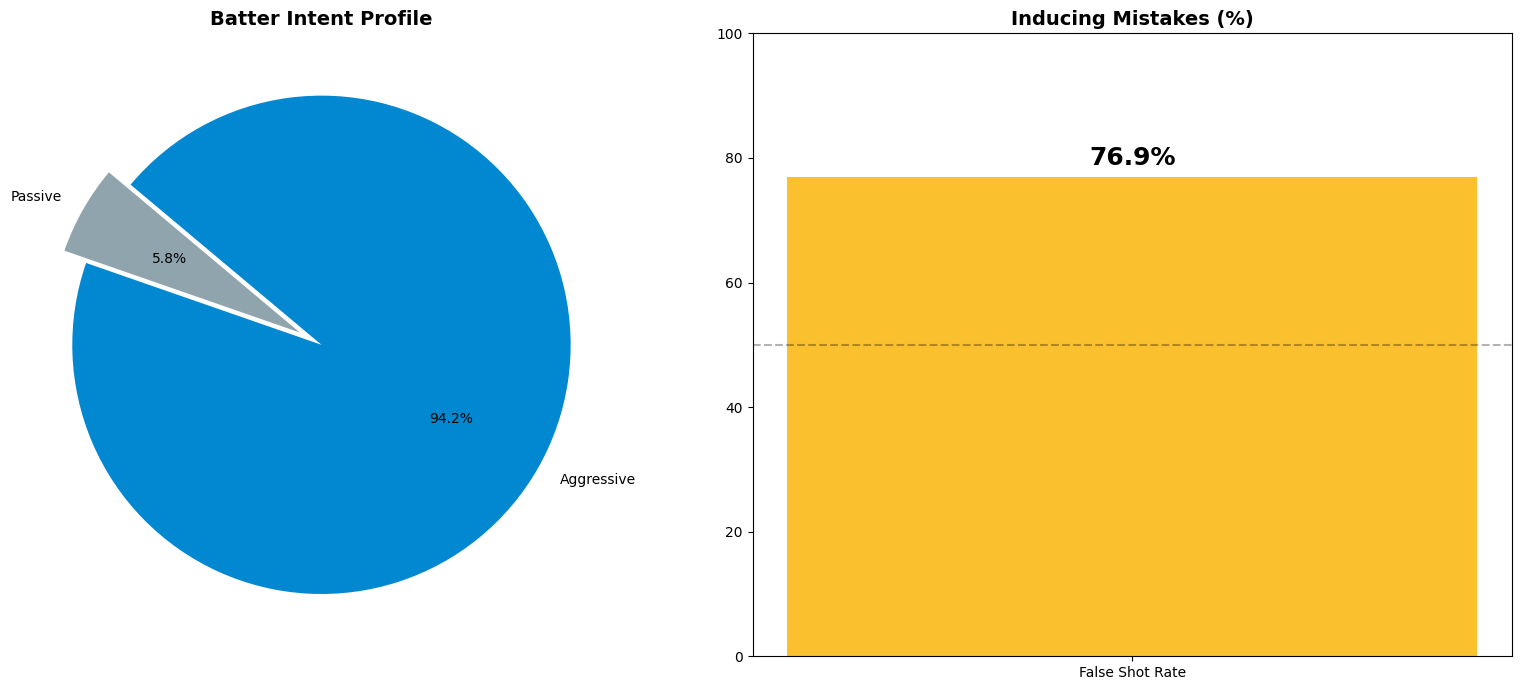

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')

# Intent Pie
ax1.pie([passive_pct, 100-passive_pct], labels=['Passive', 'Aggressive'], autopct='%1.1f%%',
        colors=['#90A4AE', '#0288D1'], startangle=140, explode=(0.1, 0))
ax1.set_title("Batter Intent Profile", fontsize=14, fontweight='bold')

# False Shot Rate Gauge (Simulated as bar)
ax2.bar(['False Shot Rate'], [false_shot_rate], color='#FBC02D')
ax2.axhline(50, color='black', linestyle='--', alpha=0.3)
ax2.set_ylim(0, 100)
ax2.set_title("Inducing Mistakes (%)", fontsize=14, fontweight='bold')
ax2.text(0, false_shot_rate + 2, f"{false_shot_rate:.1f}%", ha='center', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig('Bumrah_Intent_Dashboard.png', dpi=300)
plt.show()